# Clinical trajectories and genetic architecture across the neurological–psychiatric boundary

**Code supplement** to the manuscript submitted to *Nature Neuroscience*.

This notebook reproduces all analyses and figures in the main manuscript and supplementary materials.  
It requires the following input files (see `README.md`):
- `data/delphi_embeddings.csv` — Delphi-2M ICD-10 embeddings (120-dimensional)
- `data/genetic_correlations.xlsx` — Pairwise genetic correlation matrix from Smeland et al. (2025)

## 0. Imports and settings

In [22]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr, mannwhitneyu, wilcoxon
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from matplotlib.lines import Line2D
from adjustText import adjust_text
import os

# ── Paths ──────────────────────────────────────────────────────────────────────
# Set path_main to the repository root. Using a relative path so the notebook
# runs without modification after cloning.
path_main = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))

# ── Reproducibility ────────────────────────────────────────────────────────────
np.random.seed(42)

# ── Plot aesthetics ────────────────────────────────────────────────────────────
matplotlib.rcParams["svg.fonttype"] = "none"   # Embed fonts as text in SVGs
sns.set_theme(
    style="ticks",
    palette="colorblind",
    font_scale=1,
    font="Arial",
    rc={"axes.spines.right": False, "axes.spines.top": False}
)
plt.rcParams.update({"font.family": "Arial"})

# ── Category colours ───────────────────────────────────────────────────────────
COLOR_PSYCH = "#E74C3C"
COLOR_NEURO = "#3498DB"
COLOR_CROSS = "#7F8C8D"

## 1. Disorder definitions and ICD-10 mappings

In [23]:
# Disorder order follows Smeland et al. (2025): neurological first, then psychiatric,
# with MS, MIG, ET appended as they were not part of the original Smeland set.
phens = [
    "PD", "ALS", "ALZ", "LBD", "STROKE", "EPI",   # neurological
    "ADHD", "PTSD", "MDD", "ANX", "ASD", "SCZ",    # psychiatric
    "BD", "TS", "AN", "OCD",                         # psychiatric (cont.)
    "MS", "MIG", "ET"                                # neurological (boundary analysis)
]

PSYCHIATRIC_ALL = ["SCZ", "BD", "MDD", "ADHD", "ASD", "ANX", "PTSD", "AN", "TS", "OCD"]
NEUROLOGICAL_ALL = ["ALZ", "LBD", "PD", "ALS", "MIG", "EPI", "STROKE", "MS", "ET"]

# ICD-10 three-character codes for each GWAS phenotype.
# Notes on non-exact mappings are included inline; these are acknowledged in the
# manuscript's Online Methods and Supplementary Table 2.
disorder_to_icd = {
    "SCZ":    ["F20", "F25"],       # schizophrenia + schizoaffective
    "BD":     ["F31"],
    "MDD":    ["F32", "F33"],       # GWAS is broader (includes F34); best available mapping
    "ADHD":   ["F90"],
    "ASD":    ["F84"],
    "ANX":    ["F40", "F41"],       # phobic + other anxiety disorders
    "PTSD":   ["F43"],              # broader than GWAS (includes adjustment disorders)
    "AN":     ["F50"],              # broader than GWAS (includes other eating disorders)
    "TS":     ["F95"],
    "OCD":    ["F42"],
    "ALZ":    ["G30", "F00"],
    "LBD":    ["G31"],              # broader than GWAS (includes other G31 subtypes)
    "PD":     ["G20"],
    "ALS":    ["G12"],              # broader than GWAS (includes other motor neuron diseases)
    "MIG":    ["G43"],
    "EPI":    ["G40"],              # general + focal epilepsy merged at 3-character level
    "STROKE": ["I63", "I61", "I64"],
    "MS":     ["G35"],
    "ET":     ["G25"],              # broader than GWAS (includes other extrapyramidal disorders)
}

# Reverse mapping: ICD-10 code → disorder abbreviation
icd_to_disorder = {
    code: disorder
    for disorder, codes in disorder_to_icd.items()
    for code in codes
}

print(f"Disorders defined: {len(disorder_to_icd)}")
print(f"  Psychiatric: {PSYCHIATRIC_ALL}")
print(f"  Neurological: {NEUROLOGICAL_ALL}")

Disorders defined: 19
  Psychiatric: ['SCZ', 'BD', 'MDD', 'ADHD', 'ASD', 'ANX', 'PTSD', 'AN', 'TS', 'OCD']
  Neurological: ['ALZ', 'LBD', 'PD', 'ALS', 'MIG', 'EPI', 'STROKE', 'MS', 'ET']


## 2. Load and prepare genetic correlation matrix

In [24]:
# Load the pairwise genetic correlation (rg) matrix from Smeland et al. (2025).
# The matrix is stored with disorder abbreviations as both row and column labels.
df_rg = pd.read_excel(f"{path_main}/data/genetic_correlations.xlsx")
df_rg.set_index("rg", inplace=True)

# Set diagonal to 1.0 (self-correlation)
for d in df_rg.index:
    df_rg.loc[d, d] = 1.0

# Merge focal epilepsy (FE) and generalised genetic epilepsy (GGE) into a single
# EPI entry by averaging. This is necessary because Delphi-2M tokenises ICD-10
# codes at the three-character level (G40), which does not distinguish subtypes.
df_rg["EPI"] = (df_rg["FE"] + df_rg["GGE"]) / 2
df_rg.loc["EPI"] = (df_rg.loc["FE"] + df_rg.loc["GGE"]) / 2
df_rg = df_rg.drop(["FE", "GGE"], axis=0).drop(["FE", "GGE"], axis=1)
df_rg.loc["EPI", "EPI"] = 1.0  # restore diagonal after averaging

# Reorder rows and columns to match the canonical disorder list
df_rg = df_rg.loc[phens, phens]

print(f"Genetic correlation matrix: {df_rg.shape}")

Genetic correlation matrix: (19, 19)


## 3. Load and prepare Delphi-2M embeddings

In [25]:
# Load all Delphi-2M ICD-10 embeddings (120-dimensional vectors).
df_delphi_all = pd.read_csv(f"{path_main}/data/delphi_embeddings.csv")
emb_cols = [c for c in df_delphi_all.columns if c.startswith("emb_")]

# Extract the three-character ICD-10 prefix and map to disorder abbreviations.
df_delphi_all["icd3"] = df_delphi_all["name"].str[:3]
df_subset = df_delphi_all[df_delphi_all["icd3"].isin(icd_to_disorder)].copy()
df_subset["disorder"] = df_subset["icd3"].map(icd_to_disorder)

# For disorders with multiple ICD-10 codes (e.g., MDD: F32 + F33, STROKE: I63 + I61 + I64),
# average the corresponding embeddings to derive a single disorder-level representation.
df_delphi_embeddings = df_subset.groupby("disorder")[emb_cols].mean()

print(f"Mapped {len(df_delphi_embeddings)} disorders: {sorted(df_delphi_embeddings.index.tolist())}")

Mapped 19 disorders: ['ADHD', 'ALS', 'ALZ', 'AN', 'ANX', 'ASD', 'BD', 'EPI', 'ET', 'LBD', 'MDD', 'MIG', 'MS', 'OCD', 'PD', 'PTSD', 'SCZ', 'STROKE', 'TS']


/var/folders/jt/2kfxgzyd23d8cn2tmsvxt_tc0000gp/T/ipykernel_91384/3600759531.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_delphi_all["icd3"] = df_delphi_all["name"].str[:3]


In [26]:
# Compute pairwise cosine similarity between disorder embeddings.
# No mean-centering is applied; embeddings are used as extracted from the model.
# (Mean-centering was evaluated and did not qualitatively change results.)
emb_matrix = df_delphi_embeddings[emb_cols].values

df_delphi = pd.DataFrame(
    cosine_similarity(emb_matrix),
    index=df_delphi_embeddings.index,
    columns=df_delphi_embeddings.index
)

# Reorder to match the canonical disorder list
df_delphi = df_delphi.loc[phens, phens]

print(f"Clinical similarity matrix: {df_delphi.shape}")
print(f"Diagonal (self-similarity): {np.diag(df_delphi.values).mean():.4f} (expected 1.0)")

Clinical similarity matrix: (19, 19)
Diagonal (self-similarity): 1.0000 (expected 1.0)


## 4. Heatmaps of clinical and genetic similarity

Figure 1a–b

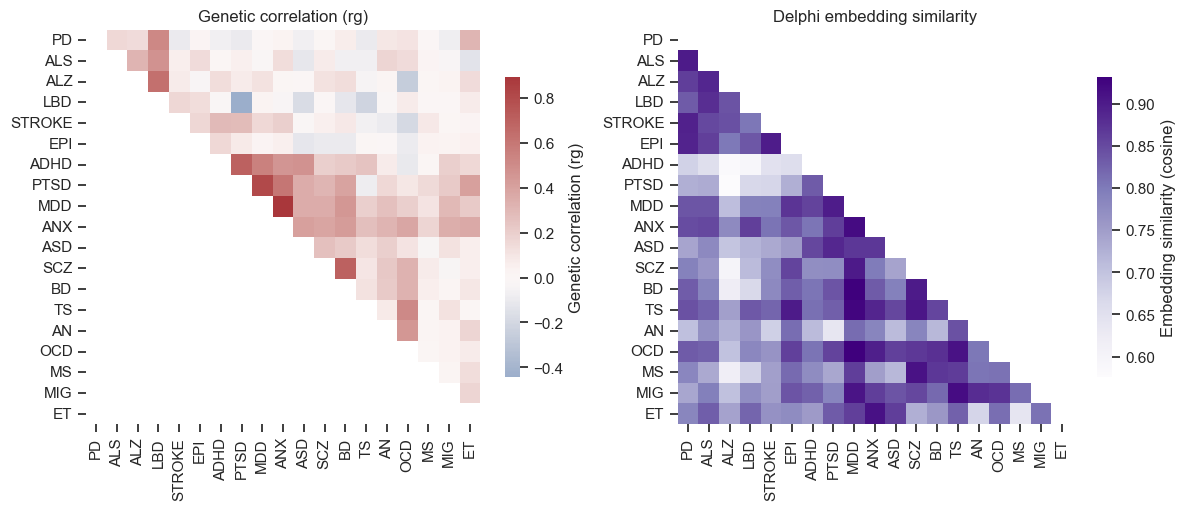

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Genetic correlation heatmap (lower triangle only, mirroring Figure 1b)
sns.heatmap(
    df_rg,
    mask=np.tril(np.ones_like(df_rg, dtype=bool)),
    cmap="vlag", center=0, square=True, ax=axes[0],
    cbar_kws={"label": "Genetic correlation (rg)", "shrink": 0.65}
)
axes[0].set(title="Genetic correlation (rg)", xlabel="", ylabel="")

# Clinical similarity heatmap (upper triangle only)
sns.heatmap(
    df_delphi,
    mask=np.triu(np.ones_like(df_delphi, dtype=bool)),
    cmap="Purples", square=True, ax=axes[1],
    cbar_kws={"label": "Embedding similarity (cosine)", "shrink": 0.65}
)
axes[1].set(title="Delphi embedding similarity", xlabel="", ylabel="")
plt.show()

## 5. Mantel test: overall correspondence between clinical and genetic similarity

In [28]:
# Extract upper triangles of both matrices (excluding diagonal) as flat vectors.
# Both matrices are symmetric, so the upper triangle contains all unique pairs.
shared = [d for d in phens if d in df_rg.index and d in df_delphi.index]
rg = df_rg.loc[shared, shared].values
emb = df_delphi.loc[shared, shared].values

idx = np.triu_indices(len(shared), k=1)
rg_upper = rg[idx]
emb_upper = emb[idx]

# Spearman correlation between the two upper triangles
r_obs, _ = spearmanr(rg_upper, emb_upper)
print(f"Observed Spearman r = {r_obs:.3f}")

# Mantel permutation test: permute rows and columns of the genetic correlation matrix
# (preserving its structure) and recompute Spearman r. The p-value is the proportion
# of permutations yielding r >= r_obs.
n_perm = 10_000
count = sum(
    spearmanr(rg[np.ix_(perm := np.random.permutation(len(shared)), perm)][idx], emb_upper)[0] >= r_obs
    for _ in range(n_perm)
)
p_mantel = (count + 1) / (n_perm + 1)

print(f"Mantel test: r = {r_obs:.3f}, p = {p_mantel:.2e} (n_perm = {n_perm:,})")
print(f"Number of disorder pairs: {len(rg_upper)}")

Observed Spearman r = 0.328
Mantel test: r = 0.328, p = 1.00e-03 (n_perm = 10,000)
Number of disorder pairs: 171


## 6. Build disorder pairs dataframe

In [29]:
# Construct a dataframe of all unique disorder pairs with their clinical and
# genetic similarity values, and label each pair by category.
psychiatric = [d for d in PSYCHIATRIC_ALL if d in shared]
neurological = [d for d in NEUROLOGICAL_ALL if d in shared]

pairs = [
    (shared[i], shared[j], rg_upper[k], emb_upper[k])
    for k, (i, j) in enumerate(zip(*idx))
]
pairs_df = pd.DataFrame(pairs, columns=["d1", "d2", "rg", "emb"])

pairs_df["category"] = pairs_df.apply(
    lambda row:
        "psych-psych" if row["d1"] in psychiatric and row["d2"] in psychiatric
        else "neuro-neuro" if row["d1"] in neurological and row["d2"] in neurological
        else "cross",
    axis=1
)

print(f"Total pairs: {len(pairs_df)}")
print(pairs_df["category"].value_counts().to_string())

Total pairs: 171
category
cross          90
psych-psych    45
neuro-neuro    36


## 7. Scatter plot: genetic vs clinical similarity by category

Supplementary Figure 1

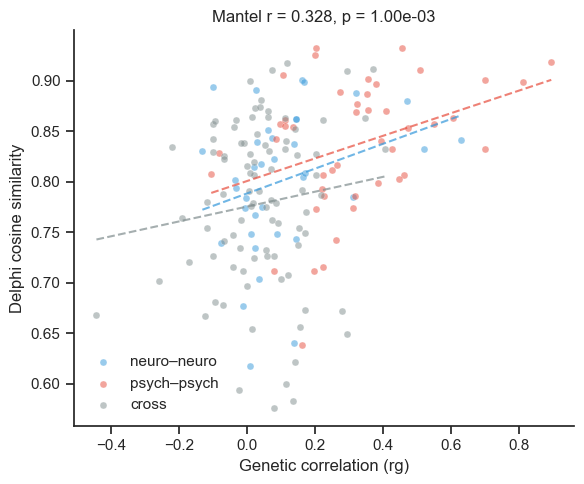

In [30]:
# Scatter plot of all disorder pairs, coloured by category (within-psych,
# within-neuro, cross-boundary). A regression line is shown per category.
colors = {
    "neuro-neuro": COLOR_NEURO,
    "psych-psych": COLOR_PSYCH,
    "cross":       COLOR_CROSS
}

fig, ax = plt.subplots(figsize=(6, 5))

for cat, col in colors.items():
    sub = pairs_df[pairs_df["category"] == cat]
    ax.scatter(sub["rg"], sub["emb"], c=col, alpha=0.5, s=25,
               label=cat.replace("-", "–"), edgecolors="white", linewidth=0.3)
    z = np.polyfit(sub["rg"], sub["emb"], 1)
    x_line = np.linspace(sub["rg"].min(), sub["rg"].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), "--", color=col, alpha=0.7, linewidth=1.5)

ax.legend(frameon=False)
ax.set_xlabel("Genetic correlation (rg)")
ax.set_ylabel("Delphi cosine similarity")
ax.set_title(f"Mantel r = {r_obs:.3f}, p = {p_mantel:.2e}")
plt.tight_layout()
plt.show()

## 8. Within-category vs cross-category similarity distributions

In [31]:
def build_category_df(matrix, psychiatric, neurological, phens):
    """
    Build a long-format dataframe of pairwise similarities labelled by category.

    Parameters
    ----------
    matrix : pd.DataFrame
        Square similarity matrix (disorders × disorders).
    psychiatric : list
        Psychiatric disorder abbreviations present in the matrix.
    neurological : list
        Neurological disorder abbreviations present in the matrix.
    phens : list
        Full ordered list of disorder abbreviations.

    Returns
    -------
    pd.DataFrame with columns: category, value, label.
    """
    psych_list = [d for d in phens if d in psychiatric]
    neuro_list = [d for d in phens if d in neurological]
    rows = []

    for i, a in enumerate(psych_list):
        for b in psych_list[i+1:]:
            rows.append({"category": "Within\npsych",
                         "value": matrix.loc[a, b], "label": f"{a}-{b}"})

    for i, a in enumerate(neuro_list):
        for b in neuro_list[i+1:]:
            rows.append({"category": "Within\nneuro",
                         "value": matrix.loc[a, b], "label": f"{a}-{b}"})

    for p in psych_list:
        for n in neuro_list:
            rows.append({"category": "Cross",
                         "value": matrix.loc[p, n], "label": f"{p}-{n}"})

    return pd.DataFrame(rows)


data_rg  = build_category_df(df_rg,    psychiatric, neurological, phens)
data_emb = build_category_df(df_delphi, psychiatric, neurological, phens)

# Print mean similarity per category for both measures
print("Mean pairwise similarity by category:")
print(f"{'Category':<20} {'Genetic (rg)':>14} {'Clinical (cosine)':>18}")
print("-" * 55)
for cat in ["Within\npsych", "Within\nneuro", "Cross"]:
    rg_mean  = data_rg[data_rg["category"]  == cat]["value"].mean()
    emb_mean = data_emb[data_emb["category"] == cat]["value"].mean()
    print(f"{cat.replace(chr(10), ' '):<20} {rg_mean:>14.3f} {emb_mean:>18.3f}")

Mean pairwise similarity by category:
Category               Genetic (rg)  Clinical (cosine)
-------------------------------------------------------
Within psych                  0.319              0.837
Within neuro                  0.105              0.801
Cross                         0.042              0.779


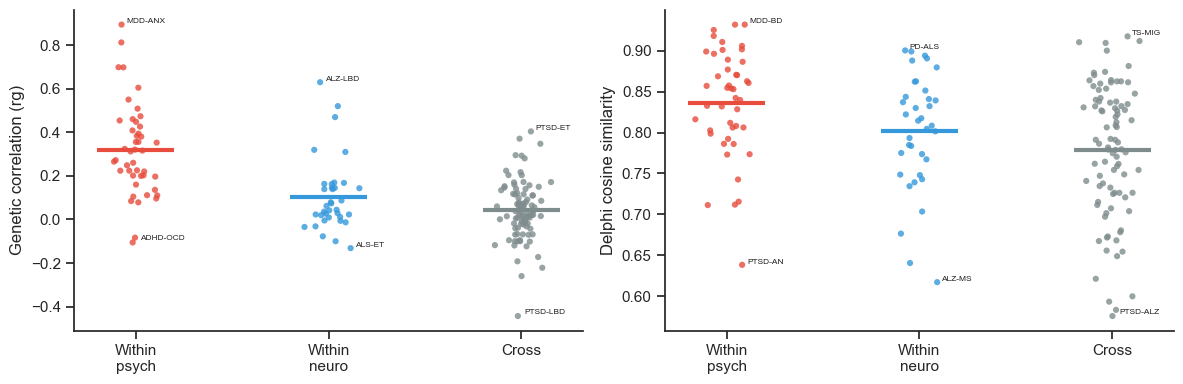


Mann-Whitney U (within > cross, clinical): U = 4749, p = 3.20e-04


In [32]:
# Strip plots: within-category vs cross-category similarity for both measures.
# Each point is a disorder pair; the horizontal bar indicates the group mean.
categories  = ["Within\npsych", "Within\nneuro", "Cross"]
cat_colors  = [COLOR_PSYCH, COLOR_NEURO, COLOR_CROSS]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (data, ylabel) in zip(axes, [
    (data_rg,  "Genetic correlation (rg)"),
    (data_emb, "Delphi cosine similarity")
]):
    texts = []
    for i, (cat, color) in enumerate(zip(categories, cat_colors)):
        sub  = data[data["category"] == cat]
        vals = sub["value"].values
        x    = np.random.normal(i, 0.06, size=len(vals))
        ax.scatter(x, vals, color=color, alpha=0.8, s=20, edgecolors="none", zorder=3)
        ax.hlines(vals.mean(), i - 0.2, i + 0.2, color=color, linewidth=3, zorder=4)

        # Label the most extreme pairs
        for idx in [sub["value"].idxmax(), sub["value"].idxmin()]:
            row   = sub.loc[idx]
            x_pos = x[sub.index.get_loc(idx)]
            texts.append(ax.text(x_pos, row["value"], row["label"], fontsize=6))

    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))
    ax.set_xticks(range(3))
    ax.set_xticklabels(categories)
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.show()

# Mann-Whitney U test: within-category vs cross-category clinical similarity
within  = data_emb[data_emb["category"] != "Cross"]["value"]
between = data_emb[data_emb["category"] == "Cross"]["value"]
u, p_mw = mannwhitneyu(within, between, alternative="greater")
print(f"\nMann-Whitney U (within > cross, clinical): U = {u:.0f}, p = {p_mw:.2e}")

## 9. Per-disorder similarity profiles

For each disorder, plot its similarity to within-category vs cross-category disorders.
Red = similarity to psychiatric disorders; blue = similarity to neurological disorders.

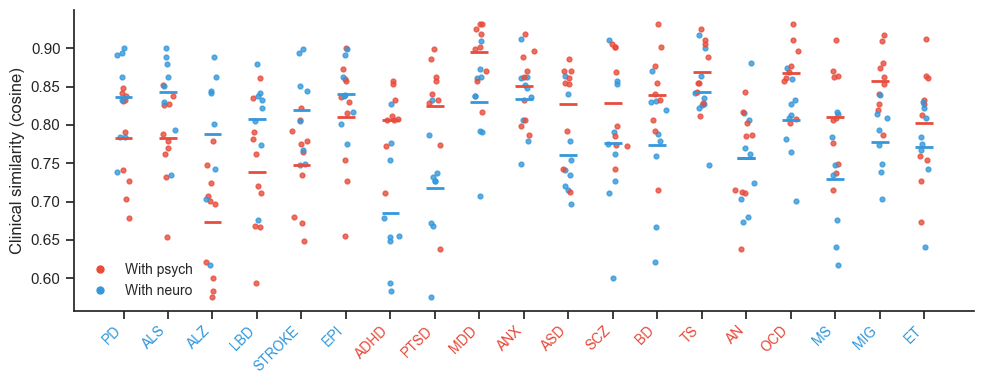

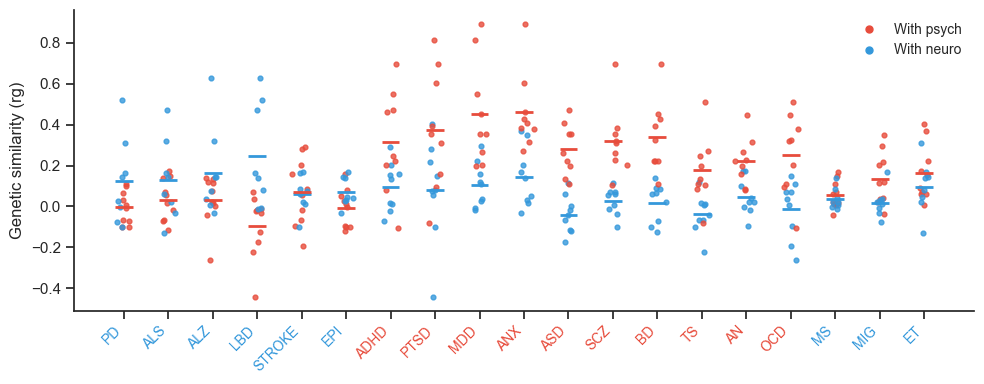

In [33]:
def plot_disorder_profiles(matrix, psychiatric, neurological, phens, ylabel, filename):
    """
    Strip plot showing each disorder's similarity to within- vs cross-category disorders.

    Each dot is a pairwise similarity value. The horizontal bar is the group mean.
    Psychiatric disorders are labelled in red; neurological in blue.
    """
    fig, ax = plt.subplots(figsize=(10, 4))
    np.random.seed(42)

    for i, d in enumerate(phens):
        if d in psychiatric:
            same, other = [p for p in psychiatric if p != d], neurological
            color_within, color_other = COLOR_PSYCH, COLOR_NEURO
        else:
            same, other = [n for n in neurological if n != d], psychiatric
            color_within, color_other = COLOR_NEURO, COLOR_PSYCH

        within_vals = matrix.loc[d, same].values
        cross_vals  = matrix.loc[d, other].values

        ax.scatter(np.random.normal(i, 0.08, size=len(cross_vals)),
                   cross_vals, color=color_other, s=12, alpha=0.8, zorder=2)
        ax.scatter(np.random.normal(i, 0.08, size=len(within_vals)),
                   within_vals, color=color_within, s=12, alpha=0.8, zorder=3)
        ax.hlines(within_vals.mean(), i - 0.2, i + 0.2,
                  color=color_within, linewidth=2, zorder=4)
        ax.hlines(cross_vals.mean(), i - 0.2, i + 0.2,
                  color=color_other, linewidth=2, zorder=4)

    ax.set_xticks(range(len(phens)))
    ax.set_xticklabels(phens, fontsize=10, rotation=45, ha="right")
    for i, label in enumerate(ax.get_xticklabels()):
        label.set_color(COLOR_PSYCH if phens[i] in psychiatric else COLOR_NEURO)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.legend(handles=[
        Line2D([0], [0], marker="o", color=COLOR_PSYCH, linestyle="", markersize=5, label="With psych"),
        Line2D([0], [0], marker="o", color=COLOR_NEURO, linestyle="", markersize=5, label="With neuro"),
    ], fontsize=10, frameon=False)

    plt.tight_layout()
    plt.show()


plot_disorder_profiles(df_delphi, psychiatric, neurological, phens,
                       "Clinical similarity (cosine)",
                       "strip_cosine_by_disorder.svg")

plot_disorder_profiles(df_rg, psychiatric, neurological, phens,
                       "Genetic similarity (rg)",
                       "strip_rg_by_disorder.svg")

## 10. Boundary strength analysis

For each disorder, boundary strength = (mean within-category similarity) − (mean cross-category similarity).
Positive values indicate the disorder is more similar to its own category (boundary holds);
negative values indicate boundary crossing.

In [34]:
def compute_boundary_strength(matrix, psychiatric, neurological):
    """
    Compute boundary strength for each disorder.

    Boundary strength = mean within-category similarity − mean cross-category similarity.
    Positive values: disorder is more similar to own category (boundary holds).
    Negative values: disorder is more similar to the other category (boundary crossing).

    Parameters
    ----------
    matrix : pd.DataFrame
        Square similarity matrix (disorders × disorders).
    psychiatric : list
        Psychiatric disorder abbreviations.
    neurological : list
        Neurological disorder abbreviations.

    Returns
    -------
    pd.DataFrame with columns: disorder, group, within, cross, diff.
    """
    results = []
    for d in psychiatric:
        others = [p for p in psychiatric if p != d]
        within = matrix.loc[d, others].mean()
        cross  = matrix.loc[d, neurological].mean()
        results.append({"disorder": d, "group": "psych",
                         "within": within, "cross": cross, "diff": within - cross})
    for d in neurological:
        others = [n for n in neurological if n != d]
        within = matrix.loc[d, others].mean()
        cross  = matrix.loc[d, psychiatric].mean()
        results.append({"disorder": d, "group": "neuro",
                         "within": within, "cross": cross, "diff": within - cross})
    return pd.DataFrame(results)


boundary_rg  = compute_boundary_strength(df_rg,    psychiatric, neurological)
boundary_emb = compute_boundary_strength(df_delphi, psychiatric, neurological)

print("Boundary strength summary:")
for label, df in [("Genetic (rg)", boundary_rg), ("Clinical (cosine)", boundary_emb)]:
    n_hold  = (df["diff"] > 0).sum()
    n_cross = (df["diff"] < 0).sum()
    crossers = df[df["diff"] < 0]["disorder"].tolist()
    print(f"\n  {label}:")
    print(f"    Boundary holds:  {n_hold}/{len(df)} disorders")
    print(f"    Boundary crossed: {n_cross}/{len(df)} disorders — {crossers}")

Boundary strength summary:

  Genetic (rg):
    Boundary holds:  15/19 disorders
    Boundary crossed: 4/19 disorders — ['MIG', 'STROKE', 'MS', 'ET']

  Clinical (cosine):
    Boundary holds:  15/19 disorders
    Boundary crossed: 4/19 disorders — ['AN', 'MIG', 'MS', 'ET']


## 11. Leave-one-disorder-out (LOO) sensitivity analysis

For each disorder, boundary strength is recomputed after removing each other disorder in turn.
The range (min, max) across LOO iterations serves as a sensitivity interval.

In [35]:
def boundary_strength_loo(matrix, psychiatric, neurological):
    """
    Leave-one-disorder-out boundary strength sensitivity analysis.

    For each disorder left out, recomputes boundary strength for all remaining
    disorders. Returns a long-format dataframe with one row per (left_out, disorder).
    """
    all_disorders = psychiatric + neurological
    results = []

    for left_out in all_disorders:
        psych_loo = [d for d in psychiatric if d != left_out]
        neuro_loo = [d for d in neurological if d != left_out]

        for d in psych_loo:
            others = [p for p in psych_loo if p != d]
            if not others:
                continue
            within = matrix.loc[d, others].mean()
            cross  = matrix.loc[d, neuro_loo].mean()
            results.append({"left_out": left_out, "disorder": d,
                             "group": "psych", "diff": within - cross})

        for d in neuro_loo:
            others = [n for n in neuro_loo if n != d]
            if not others:
                continue
            within = matrix.loc[d, others].mean()
            cross  = matrix.loc[d, psych_loo].mean()
            results.append({"left_out": left_out, "disorder": d,
                             "group": "neuro", "diff": within - cross})

    return pd.DataFrame(results)


loo_rg  = boundary_strength_loo(df_rg,    psychiatric, neurological)
loo_emb = boundary_strength_loo(df_delphi, psychiatric, neurological)


def summarize_loo(loo_df):
    """Summarise LOO results: mean, min, and max boundary strength per disorder."""
    return (
        loo_df.groupby(["disorder", "group"])["diff"]
        .agg(["mean", "min", "max"])
        .reset_index()
        .rename(columns={"min": "ci_lo", "max": "ci_hi"})
    )


loo_rg_summary  = summarize_loo(loo_rg)
loo_emb_summary = summarize_loo(loo_emb)

# Merge rg and embedding summaries for joint plotting
boundary_ci = (
    loo_rg_summary[["disorder", "group", "mean", "ci_lo", "ci_hi"]]
    .rename(columns={"mean": "rg_mean", "ci_lo": "rg_lo", "ci_hi": "rg_hi"})
    .merge(
        loo_emb_summary[["disorder", "mean", "ci_lo", "ci_hi"]]
        .rename(columns={"mean": "emb_mean", "ci_lo": "emb_lo", "ci_hi": "emb_hi"}),
        left_index=True, right_index=True
    )
)

print(f"LOO summary computed for {len(boundary_ci)} disorders")

LOO summary computed for 19 disorders


## 12. Quadrant plot: clinical vs genetic boundary strength

Figure 2a

In [36]:
row

category       Cross
value       0.575612
label       PTSD-ALZ
Name: 92, dtype: object

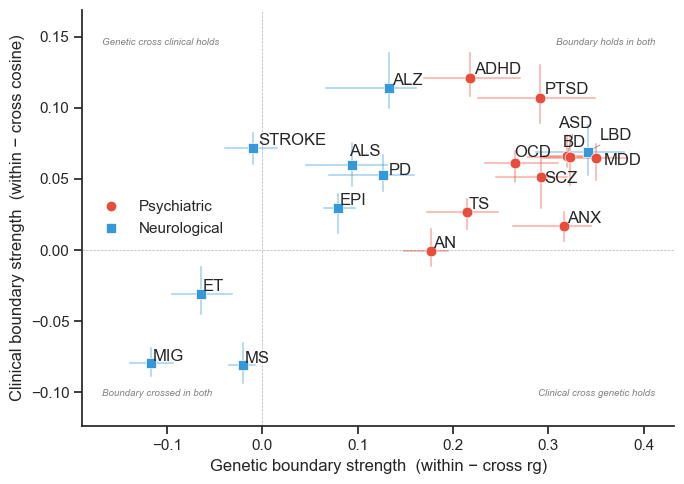

In [37]:
# Quadrant plot: each disorder is positioned by its genetic (x-axis) and
# clinical (y-axis) boundary strength. LOO min/max ranges are shown as error bars.
# Disorders in the lower-left quadrant cross the boundary in both measures.

fig, ax = plt.subplots(figsize=(7, 5))

# Coloured quadrant backgrounds
ax.set_xlim(boundary_ci["rg_lo"].min()  - 0.05, boundary_ci["rg_hi"].max()  + 0.05)
ax.set_ylim(boundary_ci["emb_lo"].min() - 0.03, boundary_ci["emb_hi"].max() + 0.03)
xlim, ylim = ax.get_xlim(), ax.get_ylim()

# Reference lines at zero
ax.axhline(0, ls="--", color="black", alpha=0.3, linewidth=0.5)
ax.axvline(0, ls="--", color="black", alpha=0.3, linewidth=0.5)

# Quadrant labels
offset = 0.02
ax.text(xlim[1] - offset, ylim[1] - offset, "Boundary holds in both",
        ha="right", va="top",   color="gray", style="italic", fontsize=7)
ax.text(xlim[0] + offset, ylim[0] + offset, "Boundary crossed in both",
        ha="left",  va="bottom", color="gray", style="italic", fontsize=7)
ax.text(xlim[0] + offset, ylim[1] - offset, "Genetic cross clinical holds",
        ha="left",  va="top",   color="gray", style="italic", fontsize=7)
ax.text(xlim[1] - offset, ylim[0] + offset, "Clinical cross genetic holds",
        ha="right", va="bottom", color="gray", style="italic", fontsize=7)

# Error bars and points per disorder
texts = []
for _, row in boundary_ci.iterrows():
    color  = COLOR_PSYCH if row["group"] == "psych" else COLOR_NEURO
    marker = "o" if row["group"] == "psych" else "s"

    # LOO range as error bars
    ax.plot([row["rg_lo"],  row["rg_hi"]],  [row["emb_mean"], row["emb_mean"]],
            color=color, alpha=0.35, linewidth=1.5, zorder=1)
    ax.plot([row["rg_mean"], row["rg_mean"]], [row["emb_lo"],  row["emb_hi"]],
            color=color, alpha=0.35, linewidth=1.5, zorder=1)

    # Disorder point
    ax.scatter(row["rg_mean"], row["emb_mean"], c=color, marker=marker,
               s=60, edgecolors="white", linewidth=0.5, zorder=3)

    texts.append(ax.text(row["rg_mean"], row["emb_mean"], row["disorder_x"]))

adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

ax.set_xlabel("Genetic boundary strength  (within − cross rg)")
ax.set_ylabel("Clinical boundary strength  (within − cross cosine)")
ax.legend(handles=[
    Line2D([0], [0], marker="o", color=COLOR_PSYCH, linestyle="", markersize=6, label="Psychiatric"),
    Line2D([0], [0], marker="s", color=COLOR_NEURO, linestyle="", markersize=6, label="Neurological"),
], frameon=False)

plt.tight_layout()
plt.show()

## 13. Psychiatric pull plot

Figure 2b

For each disorder, compute the difference between its mean similarity to psychiatric disorders
and its mean similarity to neurological disorders. Positive values indicate greater similarity
to psychiatric disorders (crossing the boundary); negative values indicate greater similarity
to neurological disorders.

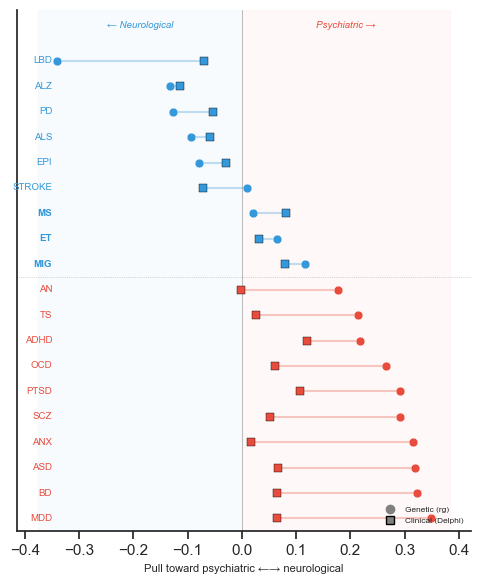

In [38]:
def compute_pull(matrix, psychiatric, neurological):
    """
    Compute psychiatric pull for each disorder.

    Pull = mean similarity to psychiatric disorders − mean similarity to neurological disorders.
    Positive: more similar to psychiatric. Negative: more similar to neurological.
    """
    results = []
    for d in psychiatric + neurological:
        psych_others = [p for p in psychiatric if p != d]
        neuro_others = [n for n in neurological if n != d]
        pull  = matrix.loc[d, psych_others].mean() - matrix.loc[d, neuro_others].mean()
        group = "psych" if d in psychiatric else "neuro"
        results.append({"disorder": d, "group": group, "pull": pull})
    return pd.DataFrame(results)


pull_rg  = compute_pull(df_rg,    psychiatric, neurological)
pull_emb = compute_pull(df_delphi, psychiatric, neurological)

pull = (
    pull_rg[["disorder", "group", "pull"]].rename(columns={"pull": "genetic"})
    .assign(clinical=pull_emb["pull"].values)
    .sort_values(["group", "genetic"], ascending=[False, False])
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(5, 6))

for i, (_, row) in enumerate(pull.iterrows()):
    color = COLOR_PSYCH if row["group"] == "psych" else COLOR_NEURO

    # Connecting line between genetic and clinical pull
    ax.plot([row["genetic"], row["clinical"]], [i, i],
            color=color, alpha=0.3, linewidth=1.5, zorder=1)

    # Genetic: circle
    ax.scatter(row["genetic"], i, marker="o", color=color, s=40,
               edgecolors="white", linewidth=0.3, zorder=3)

    # Clinical: square
    ax.scatter(row["clinical"], i, marker="s", color=color, s=40,
               edgecolors="black", linewidth=0.3, zorder=3)

    ax.text(-0.35, i, row["disorder"], fontsize=7, ha="right", va="center",
            color=color,
            fontweight="bold" if row["disorder"] in ["MIG", "MS", "ET"] else "normal")

# Boundary at zero
ax.axvline(0, ls="-", color="black", alpha=0.3, linewidth=0.5)
xlim = ax.get_xlim()
ax.axvspan(xlim[0], 0, alpha=0.03, color=COLOR_NEURO)
ax.axvspan(0, xlim[1], alpha=0.03, color=COLOR_PSYCH)

# Separator between psychiatric and neurological groups
n_psych = len(pull[pull["group"] == "psych"])
ax.axhline(n_psych - 0.5, ls=":", color="black", alpha=0.3, linewidth=0.5)

ax.text(xlim[0] * 0.5, len(pull) + 0.3, "← Neurological", fontsize=7,
        ha="center", color=COLOR_NEURO, style="italic")
ax.text(xlim[1] * 0.5, len(pull) + 0.3, "Psychiatric →",  fontsize=7,
        ha="center", color=COLOR_PSYCH, style="italic")

ax.legend(handles=[
    Line2D([0], [0], marker="o", color="gray", linestyle="", markersize=6, label="Genetic (rg)"),
    Line2D([0], [0], marker="s", color="gray", linestyle="", markersize=6,
           markeredgecolor="black", label="Clinical (Delphi)"),
], fontsize=6, frameon=False, loc="lower right")

ax.set_yticks([])
ax.set_xlabel("Pull toward psychiatric ←→ neurological", fontsize=8)
ax.set_ylim(-0.5, len(pull) + 1)
plt.tight_layout()
plt.show()